In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:53: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:53: SyntaxWarning: invalid escape sequence '\s'
/var/folders/0p/d5x2m4tx5kg1246bplsvyfyh0000gq/T/ipykernel_35675/3780236723.py:28: SyntaxWarning: invalid escape sequence '\l'
  labels = ['$|X|\leq \sigma$ ($\leq$ 66\%)', '$|X|\leq 2\sigma$ ($\leq$95\%)', '$|X|\leq 3\sigma$ ($\leq$99\%)']
/var/folders/0p/d5x2m4tx5kg1246bplsvyfyh0000gq/T/ipykernel_35675/3780236723.py:28: SyntaxWarning: invalid escape sequence '\l'
  labels = ['$|X|\leq \sigma$ ($\leq$ 66\%)', '$|X|\leq 2\sigma$ ($\leq$95\%)', '$|X|\leq 3\sigma$ ($\leq$99\%)']
/var/folders/0p/d5x2m4tx5kg1246bplsvyfyh0000gq/T/ipykernel_35675/3780236723.py:28: SyntaxWarning: invalid esca

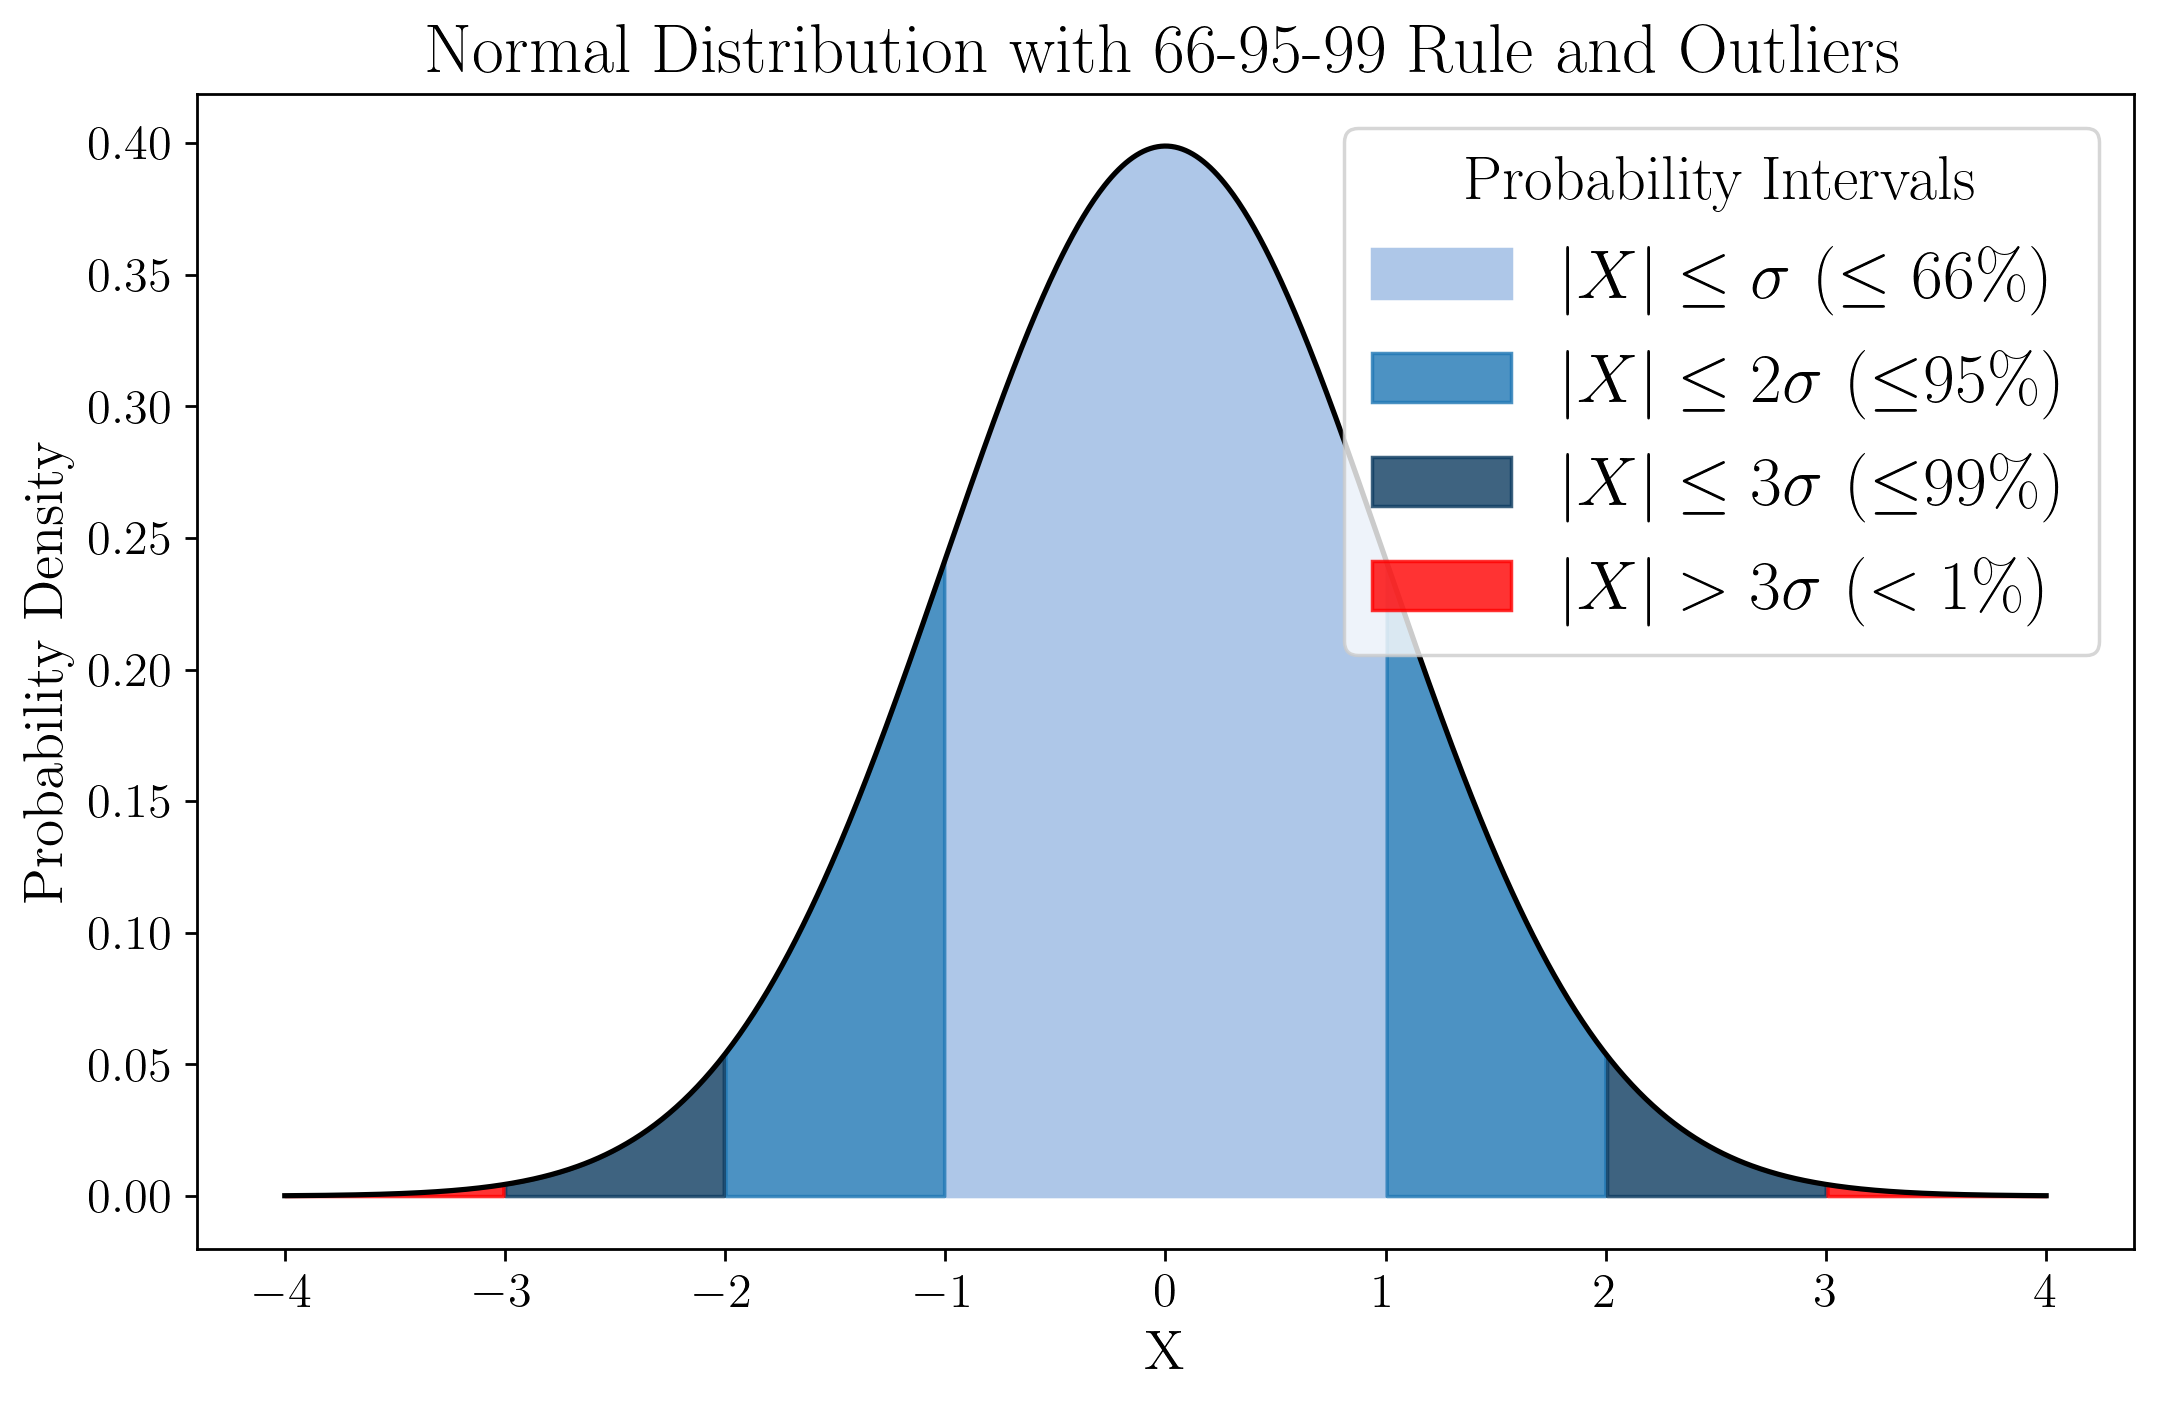

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",  # Use a serif font
    "font.serif": ["Times New Roman"],  # Specify the serif font
})

# Define the mean and standard deviation
mean = 0
std_dev = 1

# Generate x values from -4 to 4 standard deviations
x = np.linspace(mean - 4*std_dev, mean + 4*std_dev, 1000)
y = norm.pdf(x, mean, std_dev)

# Define the intervals for the 66-95-99 rule
intervals = [
    (-std_dev, std_dev, 0.66),    # 66%
    (-2*std_dev, 2*std_dev, 0.95), # 95%
    (-3*std_dev, 3*std_dev, 0.99)  # 99%
]

# Shades for each interval
colors = ['#aec7e8', '#1f77b4', '#0d3c61']
labels = ['$|X|\leq \sigma$ ($\leq$ 66\%)', '$|X|\leq 2\sigma$ ($\leq$95\%)', '$|X|\leq 3\sigma$ ($\leq$99\%)']


fig, ax = plt.subplots(figsize=(10, 6), dpi=250)
ax.plot(x, y, color='black', lw=1.5)

# Shade the outlier areas outside the 99% interval
outlier_mask_left = x <= -3*std_dev
outlier_mask_right = x >= 3*std_dev

# Fill areas within 66-95-99 rule intervals
for index, ((start, end, prob), color, label) in enumerate(list(zip(intervals, colors, labels))):
    if index == 0:
        mask = (x >= start) & (x <= end)
        ax.fill_between(x[mask], y[mask], color=color, alpha=1, label=f'{label}')
    if index != 0:
        
        # Shade the outlier areas outside the 99% interval
        mask_left = (x >= start) & (x <= start + std_dev)
        ax.fill_between(x[mask_left], y[mask_left], color=color, alpha=0.8, label=f'{label}')
        mask_right = (x >= end - std_dev) & (x <= end)
        ax.fill_between(x[mask_right], y[mask_right], color=color, alpha=0.8)


# Shade the outlier areas outside the 99% interval
ax.fill_between(x[outlier_mask_left], y[outlier_mask_left], color='red', alpha=0.8, label='$|X| > 3\sigma$ ($<1\%$)')
ax.fill_between(x[outlier_mask_right], y[outlier_mask_right], color='red', alpha=0.8)

# Set font sizes for title, labels, and legend
ax.set_title('Normal Distribution with 66-95-99 Rule and Outliers', fontsize=20)
ax.set_xlabel('X', fontsize=16)
ax.set_ylabel('Probability Density', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.legend(title="Probability Intervals", title_fontsize=18, fontsize=20)

plt.show()



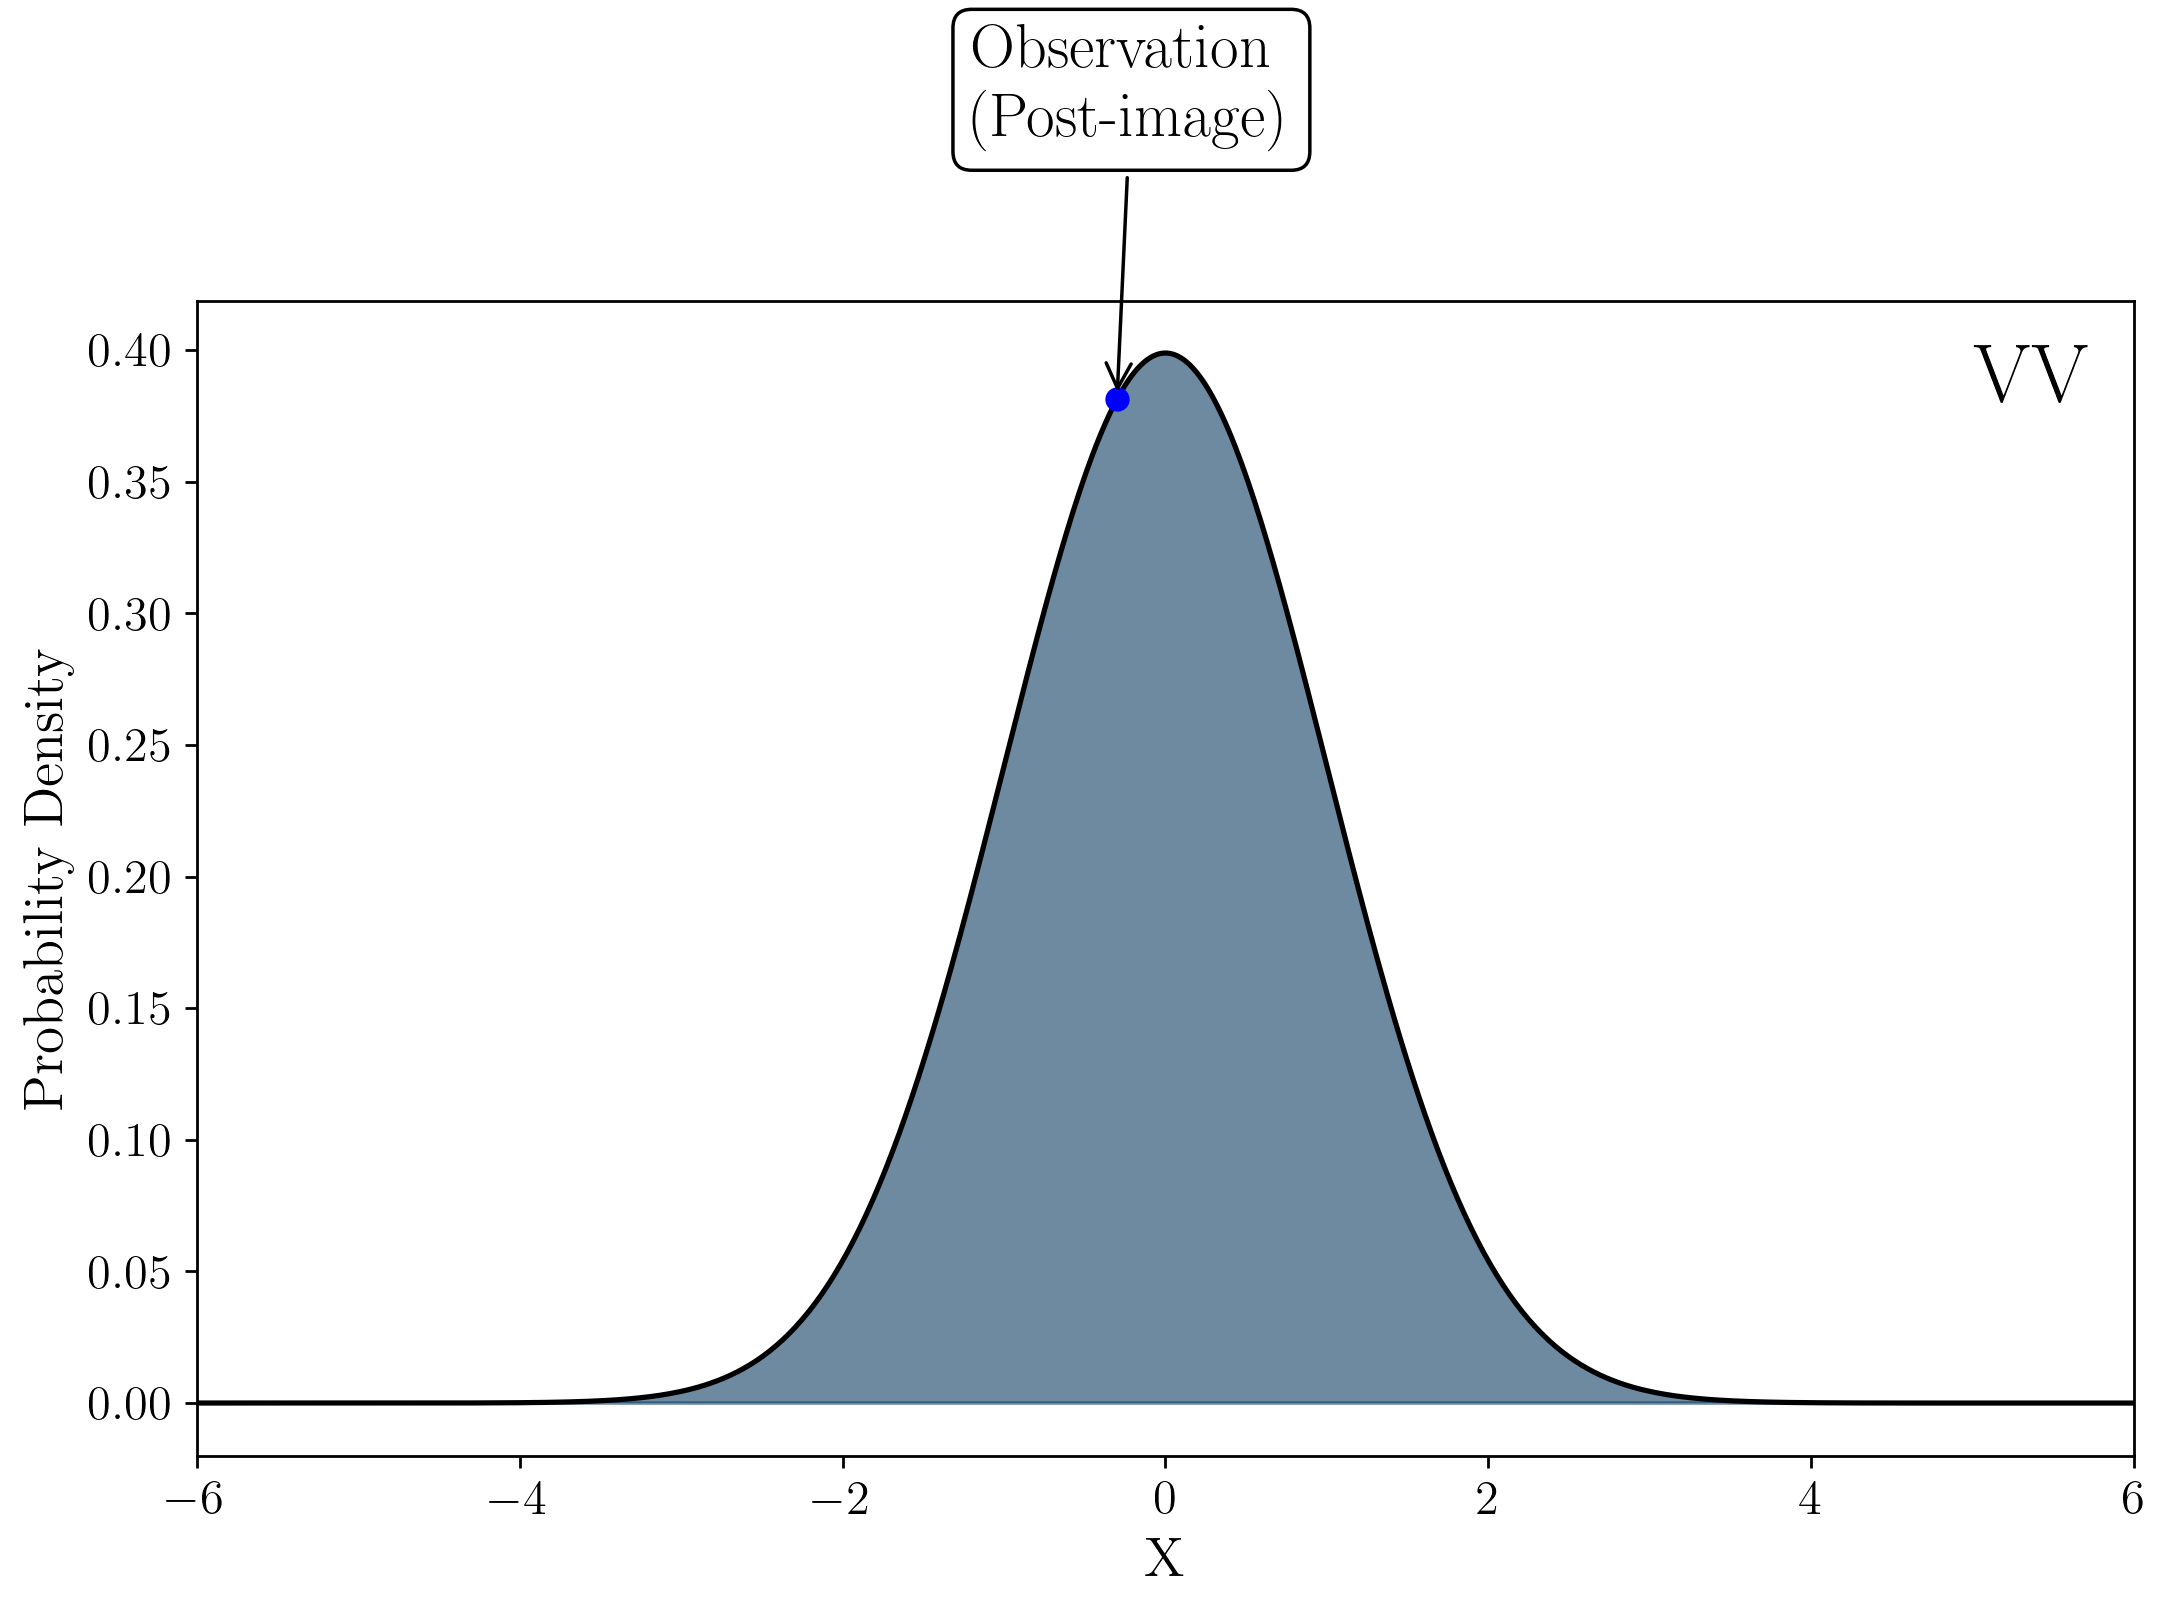

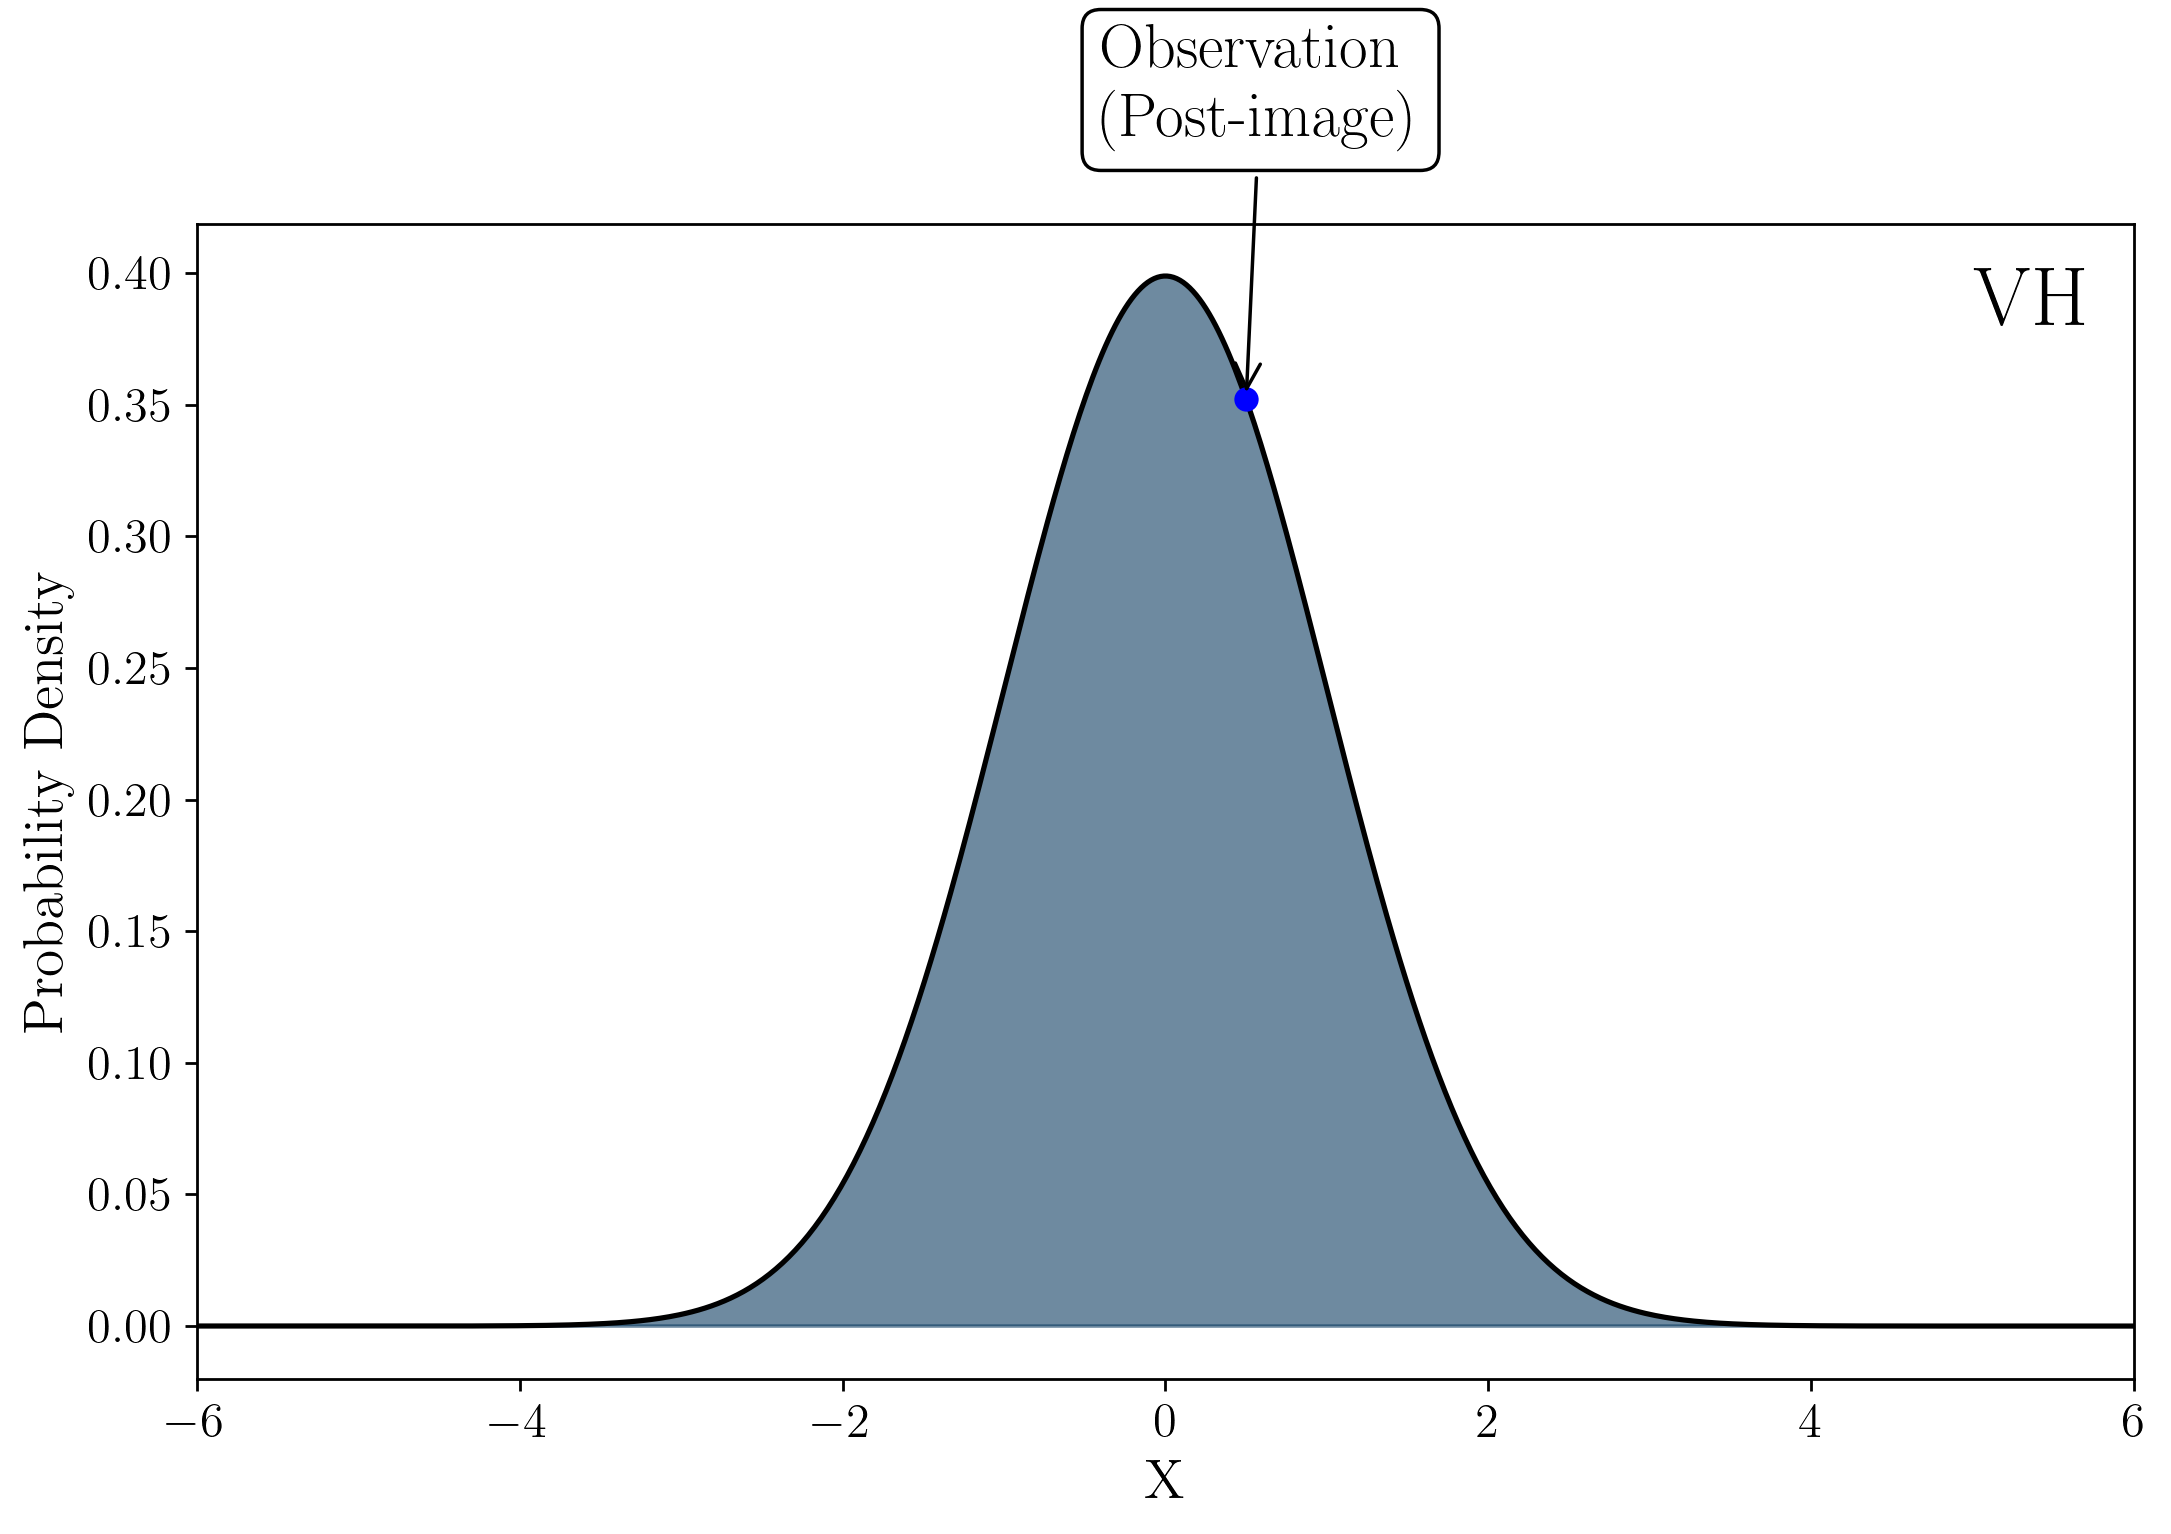

In [65]:
for p, pol in zip([-.3, .5], ['VV', 'VH']):
    # Define a point to annotate and text label
    point_x = p  # Example x-value; can be adjusted
    point_y = norm.pdf(point_x, mean, std_dev)  # Corresponding y-value
    annotation_text = "Observation\n(Post-image)"  # Example annotation text; can be adjusted
    
    # Generate x values from -4 to 4 standard deviations
    x = np.linspace(mean - 10*std_dev, mean + 10*std_dev, 1000)
    y = norm.pdf(x, mean, std_dev)
    
    # Plot settings
    fig, ax = plt.subplots(figsize=(10, 6), dpi=250)
    ax.plot(x, y, color='black', lw=1.5)
    
    # Fill entire area under the curve with darkest blue
    ax.fill_between(x, y, color=colors[2], alpha=0.6)  # darkest shade of blue used previously
    
    # Plot the point on the curve with an arrow pointing to it
    ax.plot(point_x, point_y, 'o', color='blue')  # red dot at the point
    ax.annotate(
        annotation_text,
        xy=(point_x, point_y),
        xytext=(point_x - .9, point_y + 0.1),
        arrowprops=dict(arrowstyle="->", color='black'),
        fontsize=18,
        color='black',
        bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white")
)
    
    
    ax.text(5, .38, pol, fontsize=24)
    
    # Axis labels only
    ax.set_xlabel('X', fontsize=16)
    ax.set_ylabel('Probability Density', fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_xlim(-6, 6)
    
    plt.show()


In [ ]:
# Define a point to annotate and text label
point_x = 5  # Example x-value; can be adjusted
point_y = norm.pdf(point_x, mean, std_dev)  # Corresponding y-value
annotation_text = "Observation"  # Example annotation text; can be adjusted

# Generate x values from -4 to 4 standard deviations
x = np.linspace(mean - 10*std_dev, mean + 10*std_dev, 1000)
y = norm.pdf(x, mean, std_dev)

# Plot settings
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y, color='black', lw=1.5)

# Fill entire area under the curve with darkest blue
ax.fill_between(x, y, color=colors[2], alpha=0.6)  # darkest shade of blue used previously

# Plot the point on the curve with an arrow pointing to it
ax.plot(point_x, point_y, 'o', color='blue')  # red dot at the point
ax.annotate(
    annotation_text,
    xy=(point_x, point_y),
    xytext=(point_x - .75, point_y + 0.1),
    arrowprops=dict(arrowstyle="->", color='black'),
    fontsize=14,
    color='black'
)

ax.text(5, .38, 'VV', fontsize=24)

# Axis labels only
ax.set_xlabel('X', fontsize=16)
ax.set_ylabel('Probability Density', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlim(-6, 6)

plt.show()
